In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
df = pd.read_csv('D:\ML-assignment\data\kidney_disease.csv')

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (400, 26)


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [4]:
print("=== Data Types & Non-null Counts ===")
df.info()

print("\n=== Missing Values Per Column ===")
print(df.isnull().sum())

df['classification'] = df['classification'].str.strip().str.lower()
print("\n=== Target Column Distribution ===")
print(df['classification'].value_counts())

=== Data Types & Non-null Counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17

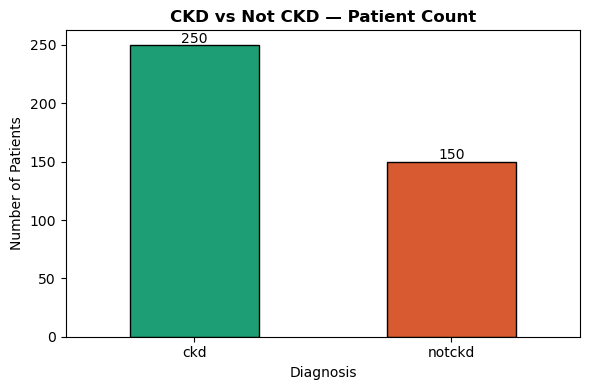

In [5]:
# Plot CKD vs Not CKD count
plt.figure(figsize=(6,4))

df['classification'].value_counts().plot(
    kind='bar',
    color=['#1D9E75', '#D85A30'],
    edgecolor='black'
)

plt.title('CKD vs Not CKD — Patient Count', fontsize=12, fontweight='bold')
plt.xlabel('Diagnosis', fontsize=10)
plt.ylabel('Number of Patients', fontsize=10)

# Improve x-axis labels
plt.xticks(rotation=0)

# Add value labels on top of bars
for index, value in enumerate(df['classification'].value_counts()):
    plt.text(index, value + 2, str(value), ha='center')

plt.tight_layout()
plt.show()

In [6]:
# Fix column names & replace '?' values
df.columns = df.columns.str.strip()

df.replace('?', np.nan, inplace=True)

# Convert numeric columns
numeric_cols = ['age','bp','sg','al','su','bgr','bu',
                'sc','sod','pot','hemo','pcv','wc','rc']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Check results
print("Data types after fix:")
print(df.dtypes)

print("\nMissing values now:")
print(df.isnull().sum())

Data types after fix:
id                  int64
age               float64
bp                float64
sg                float64
al                float64
su                float64
rbc                object
pc                 object
pcc                object
ba                 object
bgr               float64
bu                float64
sc                float64
sod               float64
pot               float64
hemo              float64
pcv               float64
wc                float64
rc                float64
htn                object
dm                 object
cad                object
appet              object
pe                 object
ane                object
classification     object
dtype: object

Missing values now:
id                  0
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc 

In [7]:
# Encode categorical (text) columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols = [c for c in categorical_cols if c != 'classification']

print("Columns to encode:", categorical_cols)

# Fill missing values before encoding (important!)
for col in categorical_cols:
    df[col].fillna('missing', inplace=True)

# Encode each column separately
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

# Clean and encode target column
df['classification'] = df['classification'].str.strip().str.lower()
df['classification'] = df['classification'].map({'ckd': 1, 'notckd': 0})

print("\nEncoding complete!")
print("Target value counts:", df['classification'].value_counts().to_dict())

Columns to encode: ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']

Encoding complete!
Target value counts: {1: 250, 0: 150}


In [8]:
# Separate features and target
X = df.drop('classification', axis=1)
y = df['classification']

print("X shape:", X.shape)
print("y shape:", y.shape)

# Impute missing values (mean strategy for numeric data)
imputer = SimpleImputer(strategy='mean')

X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

# Reset index (good practice)
X_imputed = X_imputed.reset_index(drop=True)
y = y.reset_index(drop=True)

print("\nMissing values after imputation:",
      X_imputed.isnull().sum().sum())

X shape: (400, 25)
y shape: (400,)

Missing values after imputation: 0


In [9]:
# Split FIRST
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Impute (fit ONLY on training)
imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# Scale (fit ONLY on training)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# 5-fold cross-validation — tests across 5 different splits
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train, y_train, cv=cv)

print("Model training complete!")
print(f"\nCross-Validation Accuracy across 5 folds:")
for i, score in enumerate(cv_scores):
    print(f"  Fold {i+1}: {score*100:.2f}%")
print(f"\nMean CV Accuracy : {cv_scores.mean()*100:.2f}%")
print(f"Std Deviation    : {cv_scores.std()*100:.2f}%")


Model training complete!

Cross-Validation Accuracy across 5 folds:
  Fold 1: 100.00%
  Fold 2: 100.00%
  Fold 3: 100.00%
  Fold 4: 100.00%
  Fold 5: 100.00%

Mean CV Accuracy : 100.00%
Std Deviation    : 0.00%


In [11]:
# Predict on test data
y_pred = model.predict(X_test)

# Predict probabilities (for ROC-AUC later)
y_prob = model.predict_proba(X_test)[:, 1]

# Display sample results
print("First 10 predictions:", y_pred[:10])
print("First 10 actual labels:", y_test.iloc[:10].values)

First 10 predictions: [0 1 1 0 1 1 0 1 1 1]
First 10 actual labels: [0 1 1 0 1 1 0 1 1 1]


In [13]:
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=['Not CKD', 'CKD']
))

roc = roc_auc_score(y_test, y_prob)
print(f"\nROC-AUC Score: {roc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 98.75%

Classification Report:
              precision    recall  f1-score   support

     Not CKD       0.97      1.00      0.98        30
         CKD       1.00      0.98      0.99        50

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80


ROC-AUC Score: 1.0000

Confusion Matrix:
[[30  0]
 [ 1 49]]


Accuracy: 98.75%

Classification Report:
              precision    recall  f1-score   support

     Not CKD       0.97      1.00      0.98        30
         CKD       1.00      0.98      0.99        50

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80



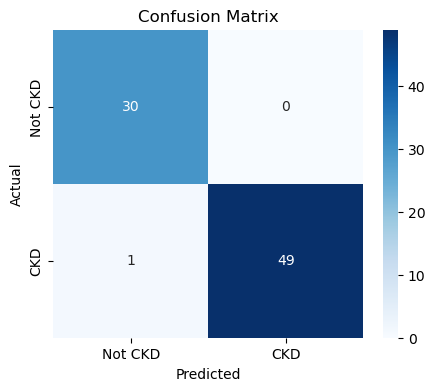

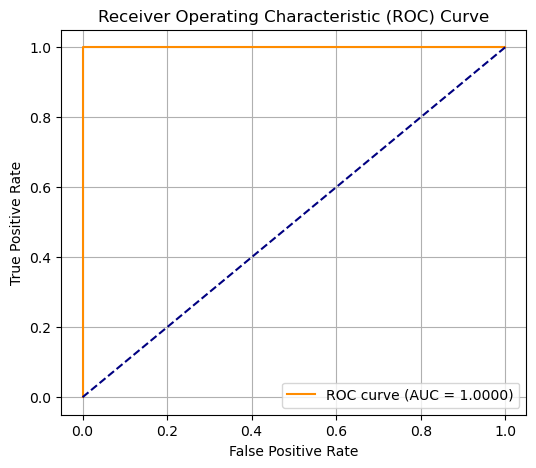

In [14]:


# 1️⃣ Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc * 100:.2f}%\n")

# 2️⃣ Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Not CKD', 'CKD']))

# 3️⃣ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not CKD', 'CKD'], yticklabels=['Not CKD', 'CKD'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

# 4️⃣ ROC Curve
roc_auc = roc_auc_score(y_test, y_prob)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0,1], [0,1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()

Top 10 most important features:
   Feature  Coefficient
0       id    -1.598102
6      rbc    -1.192383
16     pcv    -1.115701
15    hemo    -1.098843
3       sg    -0.918107
19     htn     0.726894
10     bgr     0.660508
4       al     0.626411
18      rc    -0.571911
2       bp     0.526278


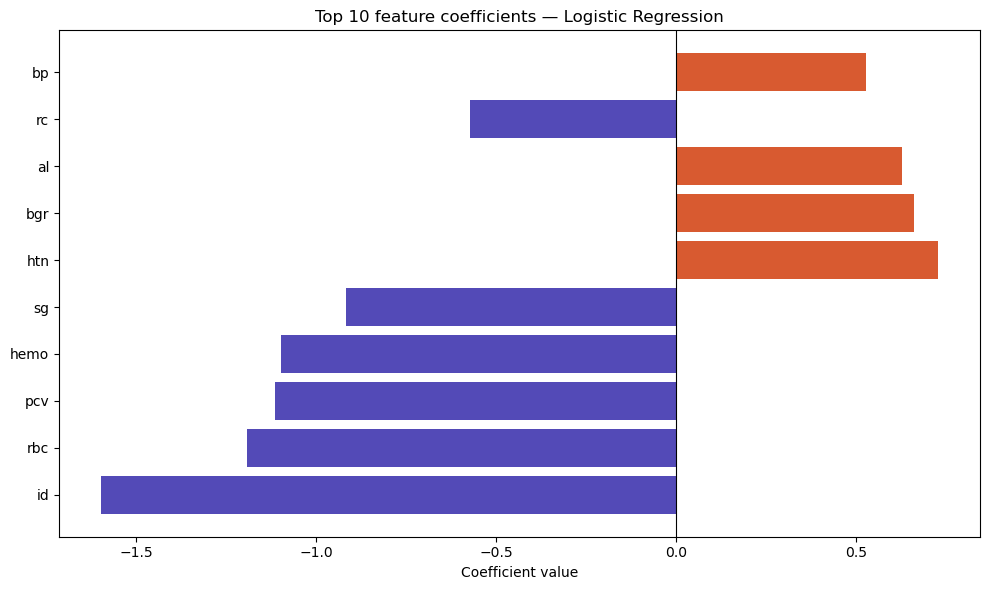

In [17]:
feature_names = X_imputed.columns
coefficients = model.coef_[0]

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Abs': np.abs(coefficients)
}).sort_values('Abs', ascending=False)

print("Top 10 most important features:")
print(coef_df[['Feature','Coefficient']].head(10).to_string())

plt.figure(figsize=(10, 6))
top10 = coef_df.head(10)
colors = ['#D85A30' if x > 0 else '#534AB7'
          for x in top10['Coefficient']]
plt.barh(top10['Feature'], top10['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 10 feature coefficients — Logistic Regression')
plt.xlabel('Coefficient value')
plt.tight_layout()
plt.show()

In [18]:
print("=" * 50)
print("  LOGISTIC REGRESSION — RESULTS SUMMARY")
print("=" * 50)
print(f"  Dataset       : Chronic Kidney Disease")
print(f"  Total samples : {len(df)}")
print(f"  Train/Test    : 80% / 20%")
print(f"  Features used : {X_train.shape[1]}")
print("-" * 50)
print(f"  Accuracy      : {accuracy_score(y_test,y_pred)*100:.2f}%")
print(f"  ROC-AUC       : {roc_auc_score(y_test,y_prob):.4f}")
tn,fp,fn,tp = confusion_matrix(y_test,y_pred).ravel()
print(f"  True Positives  (CKD correctly detected)  : {tp}")
print(f"  True Negatives  (Healthy correctly cleared): {tn}")
print(f"  False Positives (Healthy wrongly flagged)  : {fp}")
print(f"  False Negatives (CKD missed)               : {fn}")
print("=" * 50)

  LOGISTIC REGRESSION — RESULTS SUMMARY
  Dataset       : Chronic Kidney Disease
  Total samples : 400
  Train/Test    : 80% / 20%
  Features used : 25
--------------------------------------------------
  Accuracy      : 98.75%
  ROC-AUC       : 1.0000
  True Positives  (CKD correctly detected)  : 49
  True Negatives  (Healthy correctly cleared): 30
  False Positives (Healthy wrongly flagged)  : 0
  False Negatives (CKD missed)               : 1
